ESERCIZIO GUIDATO: CLASSIFICAZIONE IMMAGINI CON CCN + TRANSFER LEARNING

Nel DeepLearning il TransferLearning è imparare dal maestro per creare un capolavoro.
Prendi un cervollo che ha già visto un milione di immagini e gli insegni a risolvere un problema specifico.

- Integrazione modelli pre-addestrati, tramite TranserLearning
- Stategia di Fine-Tuning
- Analisi avanzata delle performance curve roc e precisione recall

Oggi non ha senso pertire da zero.
Sfruttare la conoscenza globale per problemi locali.
Il Transfer Learning ci permette di utilizzare un modello preaddestrato su dataset mastodontici come ImageNet come estrattore di feature generiche. Questo riduce drasticamente il tempo di addestramento.
In questa prima fase,, agiamo con produnza, manteniamo congelati i pesi della base convoluzionale, concentrandoci esclusivamente sull'addestramento del nuovo clafficatore (head) che mapperà le feature estratte sulle nostre classi specifiche.

Dal Estrattore al Classificatore
E' come fare un trapianto di cervello
Pipeline di costruzione del modello
- Base Convoluzionale: prendiamo una base convoluzionele potente, come MobileNetV2 o ResNet50, e  togliamo i layer finale, quello che serviva per le 1.000 classi originali.
- Layer di Pooling Globale: al posto del layer finale tolto al punto precednete, mettiamo un layer di pooling globale, che trasforma le mappe di feature tridimensionali in un vettore denso monodimensionale. Riassume l'informazione spaziale in un unico vettore
- Freezing: tecnica che impedisce l'aggiornamento dei pesi della base pre-addestrata per preservare i pattern visivi già appresi. Dico al modello di non cambiare ciò che sa già vedere, e di concentrarsi solo sul capire i nuovi dait.
- Classificatore Custom: aggiunta di layer Dense con Dropout per adattare l'output al numero di classi del nostro dataset specifico.

Ma cosa succede dentro questi strati mentre i dati scorrono?

Meccanica del Feature Extraction
Immagine che l'immagine, attraversando le rete, venga distillata. Entra le immagini ed esce un vettore delle caratteristiche, una sequenza di numeri che non descrive più i colori ma i concetti astratti.
Il vantaggio computazione è immenso, il nostro training è veloce e richiede poca memoria.

Ma quale maestro dobbiamo scegliere come base?
Efficienza vs Accuratezza
Non tutti i modelli pre-addestrati sono uguali. MobileNetV2 è ottimizzato per dispositivi mobili, mentre ResNet eccelle in compiti dove la profondità è cruciale.
La scelta deve basarsi sul compromesso tra il numero di parametri e la precisione richiesta dal dominio applicativo.
Si deve bilanciare il numero di parametri con l'accuratezza richiesta

Una volta che il modello ha imparato le basi, passiamo alla fase avanzata, la messa a punto

Tuning fine dei pesi
Sbloccare il potenziale degli strati profondi
Il Fine-Tuning consiste nello sbloccare alcuni degli strati superiori della base pre-addestrata per permettere loro di adattarsi alle sfrumature specifiche del nostro nuovo dataset
Questa operazione è delicata e richiede un learning rate molto basso per evitare di distruggere le feature preziose apprese durante il pre-addestramento iniziale.
In fine-tuning è l'arte della rifinitura. E' come permettere ad un esperto di cambiare leggermente il modo di guardare le cose per adattarsi al nuovo ambiente.

La regola d'ora del fine-tuning è la gradualità

Strategie di Unfreezing
Sblocchiamo solo gli strati più alti
Adattamento selettivo
- Unfreesing Parziale: sblocco degli ultimi 10-20 layer della CNN per catturare pattern di alto livello specifici
- Learning Rate Differenziato: applicazioni di un tasso di apprendimento estremamente piccolo (es 1e-5) durante il fine-tuning. Se usiamo un tasso troppo alto la rete dimentica tutot quello che sapeva sul mondo Catastrophic forgetting
- Convergenza Graduale: il fine-tuning deve essere eseguito solo dopo che il classificatore head è stato stabilizzato
- Prevenzione del Catastrophic Forgetting: evitare che la rete dimentichi le feature generiche perdendo la capacità di generalizzare

Come gestiamo questo flusso di informazioni senza fargli perdere la Loss?
la stabilità è tutto

Gestione del Gradiente in Fine-Tuning

Stabilità del Tuning
    Un errore comune è sbloccare troppi layer subito, causando divergenza nella loss causa di gradienti troppo agressivi su pesi già ottimizzati.
Batch Normalization in Fine-Tuning: 
    è buona norma mantenere i layer di Batch Normalization in modalità inferenza anche durante il fine-tuning per mantenere stabili le statistiche del dataset originale.
Ottmizzatori Adattivi
    Ottimizzatori come Adam sono ideali in questa fase per regolare dinamicamente il passo di aggiornamento su ogni singolo peso

Ma quando dobbiamo fermarci?

Early Stopping e Monitoraggio
Evitare l'overfitting
Poichè il modello è ora molto potente e i dati specifici potrebbero essere pochi, il rischio di memorizzare il dataset è estremamente alto. Dobbiamo monitorare la loos di validazone e nel momento in cui smette di scendere fermiamo il tutto
Loss(val)<Loss(val min) -> Continue
Monitorare costantemente la validation loss è l'unico modo per capire quando interrompere l'addestramento selettivo.

Ora che il modello è pronto, come facciamo a dire con certezza quanto è bravo?

Valutazione con curve PR e ROC
Misurare la robustezza della classficazione
L'accuratezza semplice non basta per valutare un modello professionale.
Se ho 99 immagini sane ed una malata, ed il modello dice sempre 'sano' ha un'accuratezza del 99% .
Qui entrano in gioco le curve probabilistiche che ci dicono non solo quanto è stato bravo il modello, ma anche quanto è stato audace o prodente nel farlo
Dobbiamo analizzare come il modello si comporta al variare della soglia di confidenza.
Le curve ROC e Precione-Recall offrono una visione completa del trade-off tra sensibilità e precisione, permettendoci di scegliere il punto operativo ottimale.

Curva ROC
La curva ROC ci mostra la rappresentazione tra i veri positivi ed i falsi positivi. 
AUC
L'AUC (area Under Curve), area sotto la curva ROC, è il valore magico, riassume la capacità di discriminazione globale del modello
Un AUC di 1.0 significa che il modello è un indovino perfetto
Curva Precision-Recall 
è fondamentale quando il nostro dataset è sbilanciato, ci dice quanto possimo fidarci del modello.

Scegliere la soglia decisionale, significa decidere se preferiamo avere qualche falso allarme alta recall o essere sicuri solo quando siamo certi al 10% alta precision

Una curva roc l'angola in alto a sinitra rappresenta la perfezione
Piuù la curva tende verso quel punto più il modlelo è robuto
L'auc invece non è solo un numero, è una probabilità, rappresenta la possibiltà che il modello assegni un punteggiu piu alto ad un caso positivo rispetto uno negativo.
Se la curva è una diagonale piatta, il nostro modello sta tirando la moneta

Nelle fasi finali del progetto si utilizzano questi grafici per mettere a confronto diversi modelli
Analisi visiva comparativa
Sovrapporte le curve ROC di diversi modelli permette di identificare immediatamente quale architettura sia più robusta per il problema specifico.
Recall= TP/(TP+FN)
La Recall di dice quante prede abbiamo catturato
La Precision ci dice quanto colpi a vuoto abbiamo sparato
Un modello con AUC inferiore potrebbe essere preferibile se garantisce una precisioe più alta nella zona di interesse operativo.
Non esiste un equilibrio perfetto universale, dipende tutto dal contesto.


In [1]:
import os
import sys

# Deve precedere l'importazione di Keras.
os.environ["KERAS_BACKEND"] = "torch"

# Usa i certificati riconosciuti da Windows.
import truststore
truststore.inject_into_ssl()

print("Python:", sys.executable)
print("Venv:", sys.prefix)
print("Python base:", sys.base_prefix)

Python: c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Scripts\python.exe
Venv: c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv
Python base: C:\Program Files\Python312


In [2]:
from urllib.request import urlopen

url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"

with urlopen(url, timeout=30) as response:
    print("Connessione riuscita")
    print("Status:", response.status)
    print("Tipo:", response.headers.get("Content-Type"))

Connessione riuscita
Status: 200
Tipo: application/x-gzip


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1755s 10us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[INFO] Fase 1: Feature Extraction...
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.8092 - loss: 0.4048 - val_accuracy: 0.8475 - val_loss: 0.3305
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.8601 - loss: 0.3199 - val_accuracy: 0.8690 - val_loss: 0.3013
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.8730 - loss: 0.2999 - val_accuracy: 0.8650 - val_loss: 0.2992
[INFO] Fase 2: Fine-Tuning...
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 389ms/step - accuracy: 0.8083 - loss: 0.4140 - val_accuracy: 0.8295 - val_loss: 0.3980
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 95s 382ms/step - accuracy: 0.8774 - loss: 0.2913 - val_accuracy: 0.8635 - val_loss: 0.3276
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 94s 374ms/step - accuracy: 0.8972 - loss: 0.2442 - val_accuracy: 0.8810 - val_loss: 0.2918
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step


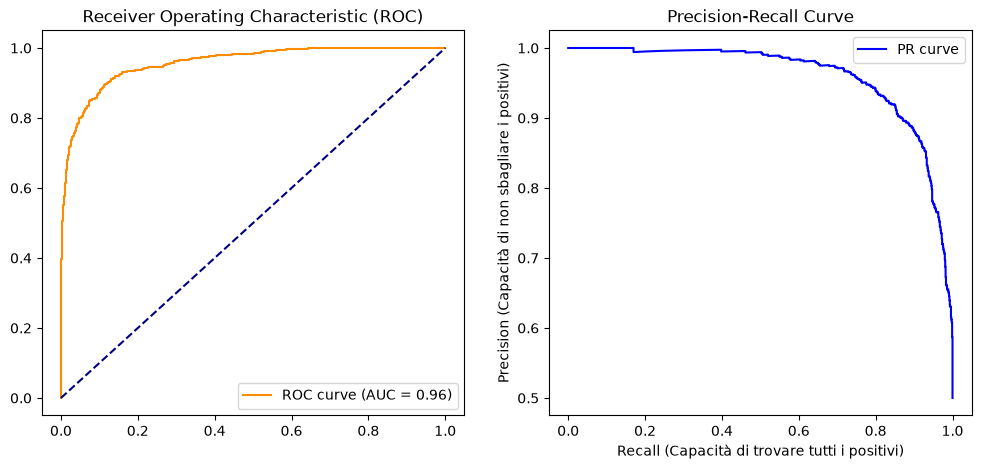

: 

In [ ]:
# *** PROBLEMA DI CLASSIFICAZIONE BINARIA ***
# Al dataset CIFAR10 filtro solo le classi C1 e C2 per farlo diventare un problema di classificazione binaria.
# Gatto o cane?
# prendo CIFAR10 come se fosse il mio dataset (dato dal mio contesto) 
#faccio transfer learning con MobileNet
import os

# Configurazione del Backend: Fondamentale nel 2026. Keras 3 è "multi-backend".
# Impostando "torch", chiediamo a Keras di tradurre i suoi layer in moduli PyTorch nativi.
# Va fatto PRIMA di importare keras perché la scelta del motore di calcolo è immutabile dopo il caricamento.
os.environ["KERAS_BACKEND"] = "torch"

import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Scarichiamo il dataset: 50.000 immagini di training e 10.000 di test (32x32 pixel a colori).
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Funzione di filtraggio binario: essenziale per restringere il dominio del problema.
def filter_binary(x, y, c1, c2):
    # Creiamo una 'maschera booleana': True solo dove la classe è c1 o c2.
    mask = (y == c1) | (y == c2)
    
    # Applichiamo la maschera per estrarre solo le immagini desiderate.
    x_filtered = x[mask.flatten()]
    
    # Trasformiamo le etichette in 0 (per gatti, c1) e 1 (per cani, c2).
    # .astype(int) converte i Booleani risultanti in numeri interi (0 e 1).
    y_filtered = (y[mask.flatten()] == c2).astype(int) 
    return x_filtered, y_filtered

# Applichiamo il filtro: Classe 3 = Cat, Classe 5 = Dog.
x_train, y_train = filter_binary(x_train, y_train, 3, 5)
x_test, y_test = filter_binary(x_test, y_test, 3, 5)


# MobileNetV2: Un modello leggero ed efficiente basato su 'Inverted Residual Blocks'.
# include_top=False: Rimuoviamo il layer finale di ImageNet (che predice 1000 classi).
# weights="imagenet": Carichiamo i pesi già ottimizzati per riconoscere forme e texture universali.
base_model = keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False, 
    weights="imagenet"
)

# CONGELAMENTO (Freezing): Impostiamo trainable=False.
# Teoria: Vogliamo che i filtri visivi della base (che sanno già distinguere forme e colori) 
# non vengano modificati durante la prima fase, altrimenti i pesi casuali del nuovo "capo" 
# invierebbero gradienti forti che distruggerebbero le conoscenze pre-esistenti.
base_model.trainable = False

# --- Pipeline Funzionale Keras ---
# Input: Definiamo la forma d'ingresso delle immagini CIFAR10 (32x32x3).
inputs = keras.Input(shape=(32, 32, 3)) 

# Resizing: MobileNetV2 è stata addestrata su immagini grandi. 
# Fare upscaling a 160x160 migliora drasticamente la qualità delle feature estratte.
x = keras.layers.Resizing(160, 160)(inputs) 

# Preprocess_input: Normalizza i pixel. MobileNet si aspetta valori nel range [-1, 1].
x = keras.applications.mobilenet_v2.preprocess_input(x) 

# Backbone: Passiamo l'immagine nel modello base. 
# training=False è critico: mantiene i layer di Batch Normalization in modalità inferenza.
x = base_model(x, training=False) 

# GlobalAveragePooling2D: Riduce la mappa di feature (es. 5x5x1280) a un vettore singolo (1280).
# Più moderno e con meno parametri rispetto a un classico layer Flatten.
x = keras.layers.GlobalAveragePooling2D()(x) 

# Dropout: Spegne casualmente il 20% dei neuroni per forzare la rete a non dipendere da singoli 
# segnali, riducendo l'overfitting (la memorizzazione a memoria dei dati).
x = keras.layers.Dropout(0.2)(x) 

# Output: Sigmoid trasforma l'output in una probabilità tra 0 e 1.
# Formula: $S(x) = \frac{1}{1 + e^{-x}}$
outputs = keras.layers.Dense(1, activation="sigmoid")(x) 

model = keras.Model(inputs, outputs)

# Compilazione Fase 1: Usiamo Adam con un Learning Rate standard (0.001).
# loss="binary_crossentropy": La funzione di costo ideale per probabilità binarie.
# Formula: $L = -\frac{1}{N} \sum_{i=1}^N [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])


# FASE 1: Addestriamo solo la "testa" del modello (i layer densi aggiunti da noi).
print("[INFO] Fase 1: Feature Extraction...")
model.fit(x_train, y_train, epochs=3, validation_split=0.2, batch_size=32)

# FASE 2: FINE-TUNING
# Teoria: Ora sblocchiamo la base per permettere al modello di specializzare i suoi filtri 
# visivi profondi sulle caratteristiche specifiche di cani e gatti di CIFAR10.
base_model.trainable = True

# Strategia: Congeliamo i primi 100 layer (che vedono linee e bordi generici) e 
# sblocchiamo solo i layer finali (che vedono strutture complesse come orecchie o musi).
for layer in base_model.layers[:100]:
    layer.trainable = False

# CRITICO: Usiamo un Learning Rate minuscolo (1e-5). 
# Un passo troppo grande distruggerebbe i pesi di ImageNet (Catastrophic Forgetting).
model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="binary_crossentropy", metrics=["accuracy"])

print("[INFO] Fase 2: Fine-Tuning...")
model.fit(x_train, y_train, epochs=3, validation_split=0.2, batch_size=32)

# Salvataggio: Il formato .keras è un pacchetto ZIP che contiene tutto il necessario per il deploy.
model.save("classifier_immagini_2026.keras")


# Predict: Otteniamo le probabilità (es. 0.85 invece di un secco "Cane").
y_pred_probs = model.predict(x_test).ravel()

# ROC Curve: Analizza il trade-off tra Veri Positivi e Falsi Positivi.
# L'AUC (Area Under Curve) indica quanto il modello è bravo a separare le due classi (1.0 è perfetto).
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve: Più indicata se le classi fossero sbilanciate.
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)

# Visualizzazione con Matplotlib
plt.figure(figsize=(12, 5))

# Sottografo ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Linea del caso (50/50)
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()

# Sottografo PR
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', label='PR curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall (Capacità di trovare tutti i positivi)')
plt.ylabel('Precision (Capacità di non sbagliare i positivi)')
plt.legend()

plt.show()